# Module 02 — the opponent atlas: exploratory analysis of the PAHdb computed libraries

**This table is parsed from the public NASA Ames PAHdb v4.00 computed library (DOI 10.3847/1538-4365/ae1c38). It is computed science data, not AI-generated, and it is the *opponent* of this project's pipeline, not its training data.**

Plan 05 (Δ-probed IR pipeline), Module 02. Inputs are the tidy tables printed by `../build_opponent_atlas.py`, `../build_line_c_table.py` and `../build_cheap_line_table.py` from the files named in `../README.md` (PAHdb theoretical 4.00, anharmonic 1.00 and experimental 3.10, obtained through the PAHdb download form; the Mai et al. 2025 Zenodo archive; the Bos et al. 2025 Supporting Information). Every source file's sha256 is in the corresponding `SUMMARY.md`. Nothing is trained in this notebook: pandas, NumPy and matplotlib only.

Sections: 1 load and clean · 2 what the library contains · 3 the scale factors as stored · 4 coverage of the plan's ladder by the four comparison lines · 5 the largest species (frozen-lines debt 6) · 6 provenance and distinctness.

In [1]:
import gzip, json, re
from pathlib import Path
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
OUT = Path("..") / "out"; FIG = Path("figures"); FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
sp = pd.read_csv(OUT / "theoretical_4.00/species.csv", dtype={"uid": str, "charge": str})
bands = pd.read_csv(OUT / "theoretical_4.00/bands.csv.gz", dtype={"uid": str, "charge": str})
an_sp = pd.read_csv(OUT / "anharmonic_1.00/species.csv", dtype={"uid": str, "charge": str})
an_bands = pd.read_csv(OUT / "anharmonic_1.00/bands.csv.gz", dtype={"uid": str, "charge": str})
ex_sp = pd.read_csv(OUT / "experimental_3.10/species.csv", dtype={"uid": str, "charge": str})
lc_sp = pd.read_csv(OUT / "lineC_mai2025/species.csv", dtype={"uid": str})
cheap_sp = pd.read_csv(OUT / "cheapline_bos2025/species.csv", dtype={"uid": str, "charge": str})
print(f"theoretical 4.00: {len(sp):,} species, {len(bands):,} bands; anharmonic 1.00: {len(an_sp)} species, {len(an_bands):,} entries; "
      f"experimental 3.10: {len(ex_sp)} species; line C: {len(lc_sp):,} species; cheap line: {len(cheap_sp)} species")

theoretical 4.00: 10,749 species, 2,517,399 bands; anharmonic 1.00: 45 species, 95,189 entries; experimental 3.10: 84 species; line C: 1,705 species; cheap line: 81 species


## 1. Load and clean

The parser already did the structural cleaning (namespace stripping, one row per transition, scale factor as its own column, basis parsed from the Gaussian route comment). Here the table-level checks: missing values, the meaning of the `formula` field, duplicates, and the rubric's size requirement (≥ 200 rows × 5 columns — met by four orders of magnitude).

In [2]:
print("species columns:", list(sp.columns)); print("band columns:", list(bands.columns))
print("\nmissing per column (species):"); print(sp.isna().sum()[sp.isna().sum() > 0])
print("\nmissing per column (bands):"); print(bands.isna().sum()[bands.isna().sum() > 0])
# the formula field carries the charge as a suffix ('C54H18-', 'C384H48+2'); the element counts were parsed from the letters and digits only
sp["formula_core"] = sp["formula"].str.replace(r"[+-]\d*$", "", regex=True)
print("\nformula strings with a charge suffix:", (sp["formula"] != sp["formula_core"]).sum(), "of", len(sp))
print("charge in field vs charge suffix agree:", ((sp["formula"].str.extract(r"([+-])(\d*)$")[0].map({"+": 1, "-": -1}).fillna(0)
       * sp["formula"].str.extract(r"([+-])(\d*)$")[1].replace("", "1").fillna("0").astype(int)) == sp["charge"].astype(int)).mean().round(4))
# isomers are not duplicates: same formula_core + charge, different uid
iso = sp.groupby(["formula_core", "charge"]).uid.nunique()
print("\n(formula, charge) groups:", len(iso), "; groups with > 1 uid (isomers):", (iso > 1).sum(), "; largest group:", iso.idxmax(), iso.max())
print("\nuid unique:", sp.uid.is_unique, "; bands with non-positive frequency:", (bands.frequency_cm <= 0).sum(), "; negative intensities:", (bands.intensity_km_mol < 0).sum())
print("\nrows x columns:", bands.shape, "(rubric: >= 200 x 5)")

species columns: ['uid', 'formula', 'charge', 'n_c', 'n_h', 'n_n', 'n_o', 'n_atoms', 'symmetry', 'method', 'basis', 'scales_seen', 'n_modes', 'weight', 'total_e', 'vib_e', 'n_solo', 'n_duo', 'n_trio', 'n_quartet', 'n_quintet', 'n_ch2', 'n_chx', 'dois', 'route', 'n_ch', 'n_ch3']
band columns: ['uid', 'formula', 'charge', 'n_c', 'frequency_cm', 'scale', 'frequency_unscaled_cm', 'intensity_km_mol', 'symmetry', 'family']

missing per column (species):
n_chx    10749
dois      3588
dtype: int64

missing per column (bands):


Series([], dtype: int64)

formula strings with a charge suffix: 6270 of 10749
charge in field vs charge suffix agree: 1.0

(formula, charge) groups: 1159 ; groups with > 1 uid (isomers): 638 ; largest group: ('C33H19', '0') 358

uid unique: True ; bands with non-positive frequency: 0 ; negative intensities: 0

rows x columns: (2517399, 10) (rubric: >= 200 x 5)


## 2. What the library contains

Species by size and charge, and where the basis set changes. The 4-31G regime — the paper's "above 200 carbons" — starts at n_C = 212 in the file; 32 species carry `chkbas` in their route line (the basis read from a checkpoint; Mg/Fe/Si complexes) and one is BP86.

charge       -1     0    1     2  3
n_c_bin                            
(0, 10]       3    39   34    12  0
(10, 20]     11   114   87    59  0
(20, 30]     21   798   41   495  0
(30, 40]     82  1660  119  1130  0
(40, 50]    111   232  232   121  2
(50, 75]    248   574  587   268  5
(75, 100]   576   862  863   587  2
(100, 150]  167   186  187   182  0
(150, 200]    7     7    7     7  0
(200, 300]    5     6    5     6  0
(300, 400]    0     1    0     1  0


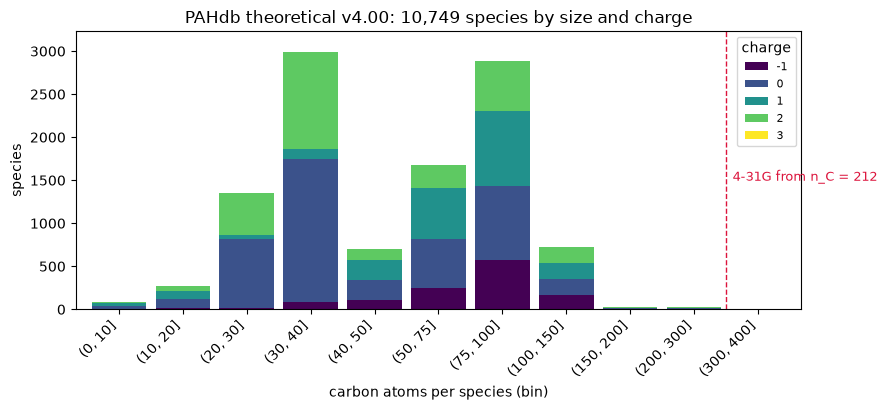

basis
6-31g*    10703
?            32
4-31g        14
Name: count, dtype: int64


In [3]:
bins = [0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300, 400]
sp["n_c_bin"] = pd.cut(sp.n_c, bins)
ct = pd.crosstab(sp["n_c_bin"], sp["charge"]).reindex(columns=["-1", "0", "1", "2", "3"], fill_value=0)
print(ct)
fig, ax = plt.subplots(figsize=(9, 4.2))
ct.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="viridis")
ax.set_xlabel("carbon atoms per species (bin)"); ax.set_ylabel("species"); ax.set_title("PAHdb theoretical v4.00: 10,749 species by size and charge")
ax.set_ylim(0, ct.sum(axis=1).max() * 1.08); ax.axvline(9.5, color="crimson", ls="--", lw=1); ax.text(9.6, ct.values.max() * 0.9, "4-31G from n_C = 212", color="crimson", fontsize=9)
ax.legend(title="charge", fontsize=8); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); fig.savefig(FIG / "fig1_species_by_size_charge.png", dpi=140); plt.show()
print(sp.basis.value_counts())

## 3. The scale factors as stored

`<frequency scale="…">` holds the scaled value. The factors actually stored for the 6-31G* species are 0.9794, 0.9691 and 0.9597, in three frequency regions; the 4-31G species carry 0.9563 / 0.9523 / 0.9595. The v4.00 paper's text, as recorded in `Frozen_Lines_to_Beat.md`, gives 0.964 / 0.979 / 0.975 — no stored transition carries those values. The library is scored as served; the paper is re-read before the pilot note.

              min        max    count
scale                                
0.9794     0.1000  1088.2211  1407844
0.9691  1076.7810  1744.3742   875211
0.9597  2590.8549  4440.3359   210279
0.9563     0.9202  1062.4713    10731
0.9523  1058.1177  1656.8650     6982
0.9097  1637.6473  2139.7592     2488
0.9595  2933.4117  3148.5128     1158
0.9908     7.0839  1095.5235      583
1.0145    21.3995  1123.7346      530
1.0051    20.0689  1566.5482      408
0.9777    32.1601  1570.1597      378
0.9780  1087.0372  1585.1158      377


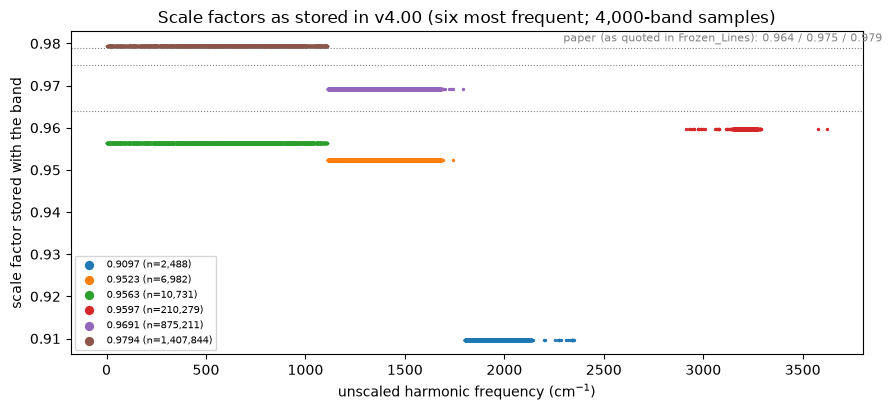

In [4]:
sc = bands.groupby("scale").frequency_cm.agg(["min", "max", "count"]).sort_values("count", ascending=False)
print(sc.head(12))
top = sc.head(3).index.tolist()
fig, ax = plt.subplots(figsize=(9, 4.2))
sub = bands[bands.scale.isin(sc.head(6).index)]
for s_, g in sub.groupby("scale"):
    ax.scatter(g.frequency_unscaled_cm.sample(min(len(g), 4000), random_state=0), [s_] * min(len(g), 4000), s=2, label=f"{s_} (n={len(g):,})")
for v in (0.964, 0.979, 0.975): ax.axhline(v, color="grey", ls=":", lw=0.8)
ax.text(3900, 0.9805, "paper (as quoted in Frozen_Lines): 0.964 / 0.975 / 0.979", fontsize=8, color="grey", ha="right")
ax.set_xlabel("unscaled harmonic frequency (cm$^{-1}$)"); ax.set_ylabel("scale factor stored with the band"); ax.set_title("Scale factors as stored in v4.00 (six most frequent; 4,000-band samples)")
ax.legend(fontsize=7, markerscale=4, loc="lower left"); plt.tight_layout(); fig.savefig(FIG / "fig2_scale_factors_as_stored.png", dpi=140); plt.show()

Band positions by family across the library (the family label is a frequency-range rule printed in the parser, a pilot-note candidate). Intensity-weighted, the library's spectrum is the familiar PAH pattern: C–H out-of-plane 11–14 µm, the 6.2 / 7.7 / 8.6 µm C–C and C–H in-plane bands, the 3.3 µm C–H stretch.

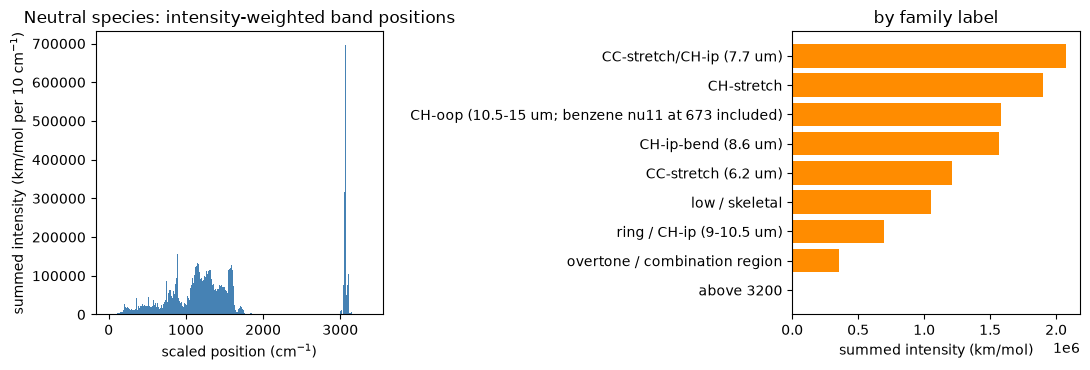

family
above 3200                                              2631.0
overtone / combination region                         356459.0
ring / CH-ip (9-10.5 um)                              697694.0
low / skeletal                                       1055432.0
CC-stretch (6.2 um)                                  1212116.0
CH-ip-bend (8.6 um)                                  1565027.0
CH-oop (10.5-15 um; benzene nu11 at 673 included)    1584844.0
CH-stretch                                           1899020.0
CC-stretch/CH-ip (7.7 um)                            2077226.0
Name: intensity_km_mol, dtype: float64


In [5]:
neutral = bands[bands.charge == "0"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(neutral.frequency_cm, bins=np.arange(0, 3400, 10), weights=neutral.intensity_km_mol, color="steelblue")
axes[0].set_xlabel("scaled position (cm$^{-1}$)"); axes[0].set_ylabel("summed intensity (km/mol per 10 cm$^{-1}$)"); axes[0].set_title("Neutral species: intensity-weighted band positions")
fam = neutral.groupby("family").intensity_km_mol.sum().sort_values()
axes[1].barh(fam.index, fam.values, color="darkorange"); axes[1].set_xlabel("summed intensity (km/mol)"); axes[1].set_title("by family label")
plt.tight_layout(); fig.savefig(FIG / "fig3_positions_by_family.png", dpi=140); plt.show()
print(fam.round(0))

## 4. Coverage of the plan's ladder by the four comparison lines

Which rung has an entry in which line (frozen Ladder §2; the lines of `Frozen_Lines_to_Beat.md`). Benzene (R0) is absent from every library except the anharmonic one — and R0 is an agreement rung (decision 28) where the comparison is printed and claims nothing.

                                       R0 benzene  R1 naphthalene  R2 pyrene  R2 C18H12 (chrysene/triphenylene/tetracene)  R3 coronene  \
A: PAHdb theoretical 4.00                       0               4          7                                           16            5   
B: PAHdb anharmonic 1.00                        1               1          2                                            1            0   
C: Mai 2025 MLMD                                0               1          2                                            7            1   
cheap: Bos 2025 SI                              0               1          3                                            6            2   
lab: PAHdb experimental 3.10 (matrix)           0               1          3                                            6            2   

                                       R4–R5 class (54–216 C)  R6 class (≥ 300 C)  
A: PAHdb theoretical 4.00                                5110                   2  
B: 

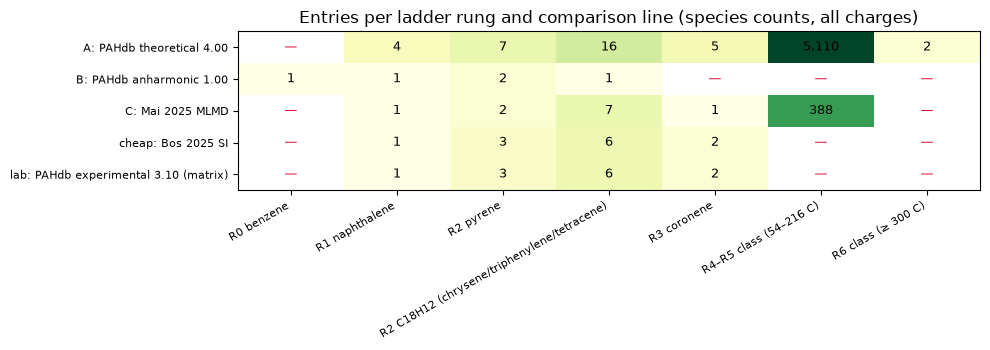

In [6]:
LADDER = [("R0 benzene", ["C6H6"]), ("R1 naphthalene", ["C10H8"]), ("R2 pyrene", ["C16H10"]), ("R2 C18H12 (chrysene/triphenylene/tetracene)", ["C18H12"]),
          ("R3 coronene", ["C24H12"]), ("R4–R5 class (54–216 C)", None), ("R6 class (≥ 300 C)", None)]
def count(df, formulas, ncol="n_c", fcol="formula", lo=None, hi=None):
    f = df[fcol].astype(str).str.replace(r"[+-]\d*$", "", regex=True)
    if formulas is not None: return int(f.isin(formulas).sum())
    return int(((df[ncol] >= lo) & (df[ncol] <= hi)).sum())
lines = {"A: PAHdb theoretical 4.00": sp, "B: PAHdb anharmonic 1.00": an_sp, "C: Mai 2025 MLMD": lc_sp, "cheap: Bos 2025 SI": cheap_sp, "lab: PAHdb experimental 3.10 (matrix)": ex_sp}
rows = []
for name, df in lines.items():
    r = {}
    for label, forms in LADDER:
        if forms is not None: r[label] = count(df, forms)
        elif "R4" in label: r[label] = count(df, None, lo=54, hi=216)
        else: r[label] = count(df, None, lo=300, hi=10_000)
    rows.append(pd.Series(r, name=name))
cov = pd.DataFrame(rows); print(cov)
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(np.where(cov.values > 0, np.log10(cov.values + 1), np.nan), cmap="YlGn", aspect="auto")
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]; ax.text(j, i, f"{v:,}" if v else "—", ha="center", va="center", fontsize=9, color="black" if v else "crimson")
ax.set_xticks(range(cov.shape[1])); ax.set_xticklabels(cov.columns, rotation=30, ha="right", fontsize=8); ax.set_yticks(range(cov.shape[0])); ax.set_yticklabels(cov.index, fontsize=8)
ax.set_title("Entries per ladder rung and comparison line (species counts, all charges)"); plt.tight_layout(); fig.savefig(FIG / "fig4_ladder_coverage.png", dpi=140); plt.show()

## 5. The largest species — frozen-lines debt 6

Is C₃₈₄H₄₈ itself in v4.00? Yes: uid 617 (neutral, 4-31G) and uid 4447 (dication). Its stored spectrum is the only prediction that exists at that size — line A alone. The count of symmetry-unique local environments the fragment-probed R6 needs is a Module-02 follow-up on the geometry (not done here).

 uid   formula charge symmetry basis  n_modes          scales_seen
 617   C384H48      0    1-A1G 4-31g     1290 0.9523,0.9563,0.9595
4447 C384H48+2      2    3-B3G 4-31g     1290 0.9523,0.9563,0.9595


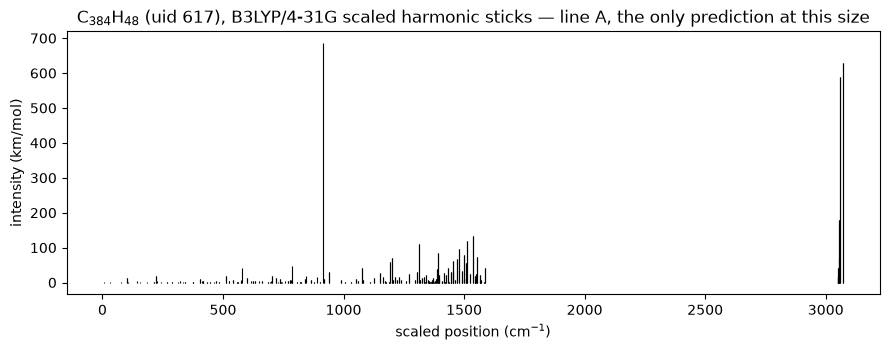

1290 modes; 230 with I > 1 km/mol; strongest: 
 frequency_cm  intensity_km_mol symmetry                                            family
     913.0444          685.3361      A2U CH-oop (10.5-15 um; benzene nu11 at 673 included)
    3071.6238          630.1399      E1U                                        CH-stretch
    3071.6238          630.1314      E1U                                        CH-stretch
    3057.1625          588.3389      E1U                                        CH-stretch
    3057.1625          588.2814      E1U                                        CH-stretch
    3053.2920          178.3402      E1U                                        CH-stretch


In [7]:
c384 = sp[(sp.n_c >= 300) & (sp.n_c <= 400)][["uid", "formula", "charge", "symmetry", "basis", "n_modes", "scales_seen"]]; print(c384.to_string(index=False))
b617 = bands[bands.uid == "617"]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.vlines(b617.frequency_cm, 0, b617.intensity_km_mol, color="black", lw=0.8)
ax.set_xlabel("scaled position (cm$^{-1}$)"); ax.set_ylabel("intensity (km/mol)"); ax.set_title("C$_{384}$H$_{48}$ (uid 617), B3LYP/4-31G scaled harmonic sticks — line A, the only prediction at this size")
plt.tight_layout(); fig.savefig(FIG / "fig5_c384h48_sticks.png", dpi=140); plt.show()
print(f"{len(b617)} modes; {int((b617.intensity_km_mol > 1).sum())} with I > 1 km/mol; strongest: ")
print(b617.sort_values("intensity_km_mol", ascending=False).head(6)[["frequency_cm", "intensity_km_mol", "symmetry", "family"]].to_string(index=False))

## 6. Provenance and distinctness

- **Source.** NASA Ames PAH IR Spectroscopic Database, computed library version 4.00 (2024-06-27), Ricca et al. 2026, ApJS 282, 7 (DOI 10.3847/1538-4365/ae1c38); anharmonic library 1.00 (2026-07-01); experimental library 3.10. Obtained 2026-09-10 through the database's download form (e-mail address and citation agreement, submitted by the student, not by any tool); the citation requirement (Boersma+ 2014, Bauschlicher+ 2018, Mattioda+ 2020, Ricca+ 2026 and per-species references) is honoured in the report. Files are identified by sha256 in each `SUMMARY.md`; the raw XML stays out of version control.
- **Not AI-generated.** The tables are parsed computed-chemistry data; no value in them was produced or altered by a model. Nothing is trained in this notebook (rubric: EDA without ML).
- **Role.** This table is the right-hand side of the plan's comparisons from naphthalene upward (the *opponent*); at benzene it is a printed comparison column only (decision 28).
- **Decision 7 (2026-09-04).** An earlier, never-submitted draft of the Foundations project on the QM9 dataset exists in the student's GitHub account; it is renamed or archived and is not this submission. This notebook is the Module-02 submission; Module 03 uses *measurements* (a different dataset with its own provenance), Module 04 a derived join table with its own identifier.